<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY_10_Feature_Importance_in_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FEATURE IMPORTANCE IN ML 📈📊


In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd

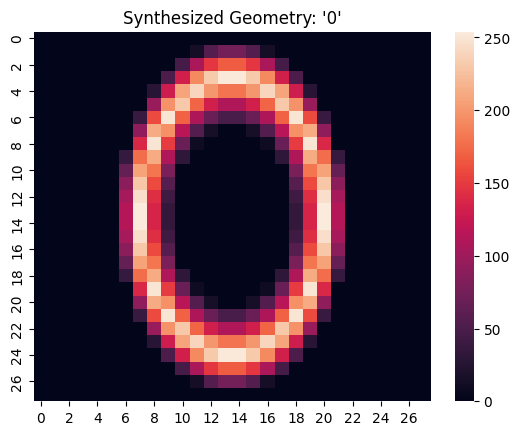

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize structural baseline
num_samples = 5
data = np.zeros((num_samples, 784), dtype=int)
labels = [1, 0, 1, 4, 0]

# 2. Execute spatial geometry synthesis for target '0'
for i in range(num_samples):
    if labels[i] == 0:
        for y in range(28):
            for x in range(28):
                # Calculate elliptical distance from the center (13.5, 13.5)
                dx = (x - 13.5) ** 2 / 6.5 ** 2
                dy = (y - 13.5) ** 2 / 10.5 ** 2
                dist = dx + dy

                # Define stroke thickness boundaries
                if 0.4 < dist < 1.6:
                    # Calculate intensity gradient (peak intensity at dist == 1.0)
                    deviation = abs(dist - 1)
                    intensity = int(255 * (1 - (deviation / 0.6)))

                    # Clamp constraints and map to 1D flat array
                    data[i, y * 28 + x] = max(0, min(255, intensity))

# 3. Construct the tabular architecture
columns = ['label'] + [f'pixel{i}' for i in range(784)]
df = pd.DataFrame(np.column_stack((labels, data)), columns=columns)

# 4. Matrix verification & visualization plotting
X_features = df.drop('label', axis=1)

# Target index 1 corresponds to label '0' in the generated dataset
heatmap_matrix = X_features.iloc[1].values.reshape(28, 28)

sns.heatmap(heatmap_matrix)
plt.title("Synthesized Geometry: '0'")
plt.show()

# Export for external utilization
df.to_csv('synthesized_digit_data.csv', index=False)

In [ ]:
# Extract the dependent target vector
y = df['label']

# Extract the independent feature matrix by dropping the target column
X = df.drop('label', axis=1)

In [ ]:
df.shape

(5, 785)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X,y)

RandomForestClassifier()

In [ ]:
rf.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.02173913, 0.01086957, 0.        , 0.01086957,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.01086957, 0.        , 0.01086957,
       0.        , 0.        , 0.01086957, 0.        , 0.     

In [ ]:
rf.feature_importances_.shape

(784,)

<Axes: >

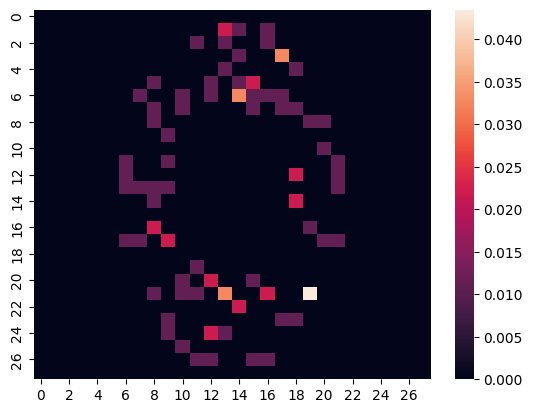

In [ ]:
sns.heatmap(rf.feature_importances_.reshape(28,28))

# 🌲📊 FEATURE IMPORTANCE IN RANDOM FOREST 📈


# 1. Decision Tree

In [ ]:
from sklearn.datasets import make_classification

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
X,y = make_classification(n_samples=5,
                          n_classes=2,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          random_state=0)

In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.894\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 1.01\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

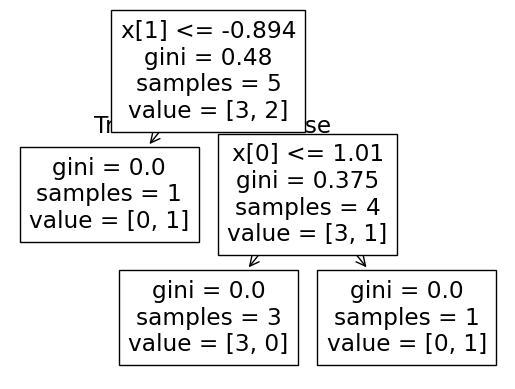

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [ ]:
clf.feature_importances_

array([0.625, 0.375])

How do we know which feature is important?
-> This means your model has 2 features.
Feature   |          Importance |
| --------- | ------------------: |
| Feature 1 | `0.625` → **62.5%** |
| Feature 2 | `0.375` → **37.5%** |
The scores add up to approximately 1.0 (100%):|

In [18]:
# How to see the feature names + importance together
feature_names = ['Feature 1', 'Feature 2']

feature_importance = pd.Series(
    clf.feature_importances_,
    index=feature_names
)

print(feature_importance)

Feature 1    0.625
Feature 2    0.375
dtype: float64


In [ ]:
# or
feature_names = [f'Feature {i+1}' for i in range(X.shape[1])]

feature_importance = pd.Series(
    clf.feature_importances_,
    index=feature_names
)

print(feature_importance)

# 2. Random Forest Classifier

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=2)
rf.fit(X,y)

RandomForestClassifier(n_estimators=2)

In [20]:
rf.feature_importances_

array([1., 0.])

| Feature   |       Importance | Meaning                                           |
| --------- | ---------------: | ------------------------------------------------- |
| Feature 1 | `1.0` → **100%** | ⭐ Completely accounts for the measured importance |
| Feature 2 |   `0.0` → **0%** | ❌ No measured contribution                        |


In [21]:
print(rf.estimators_[0].feature_importances_)
print(rf.estimators_[1].feature_importances_)

print((1 + 0.555)/2)

[0. 0.]
[1. 0.]
0.7775000000000001


# 3. Decision Tree if Features are more

In [22]:
X,y = make_classification(n_samples=15,
                          n_classes=2,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          random_state=0)

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
clf = DecisionTreeClassifier()
clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.3333333333333333, 0.875, 'x[1] <= -0.383\ngini = 0.498\nsamples = 15\nvalue = [8, 7]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[0] <= 0.878\ngini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.6666666666666666, 0.375, 'x[0] <= 2.444\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

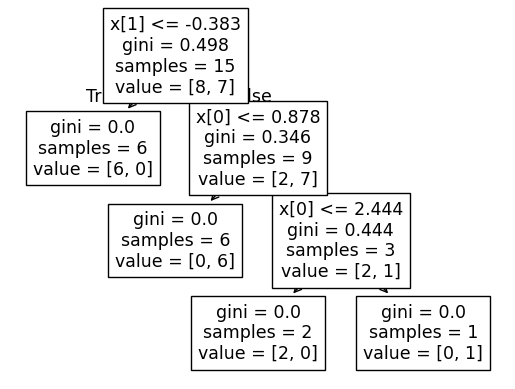

In [26]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [27]:
clf.feature_importances_

array([0.41666667, 0.58333333])